In [1]:
import torch
from torchvision import datasets, transforms

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<?, ?B/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


In [2]:
from torch import nn, optim
import torch.nn.functional as F

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        
    def forward(self, x):
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        
        return x

In [3]:
model = Classifier()

images, labels = next(iter(testloader))
# Get the class probabilities
ps = torch.exp(model(images))
# Make sure the shape is appropriate, we should get 10 class probabilities for 64 examples
print(ps.shape)

torch.Size([64, 10])


In [4]:
top_p, top_class = ps.topk(1, dim=1)
# Look at the most likely classes for the first 10 examples
print(top_class[:10,:])

tensor([[7],
        [7],
        [7],
        [7],
        [7],
        [7],
        [7],
        [7],
        [7],
        [7]])


In [5]:
equals = top_class == labels.view(*top_class.shape)

In [6]:
accuracy = torch.mean(equals.type(torch.FloatTensor))
print(f'Accuracy: {accuracy.item()*100}%')

Accuracy: 12.5%


In [7]:
model = Classifier()
criterion = nn.NLLLoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 30

train_losses, test_losses = [], []
for e in range(epochs):
    tot_train_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    else:
        tot_test_loss = 0
        test_correct = 0  # Number of correct predictions on the test set
        
        # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            for images, labels in testloader:
                log_ps = model(images)
                loss = criterion(log_ps, labels)
                tot_test_loss += loss.item()

                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                test_correct += equals.sum().item()

        # Get mean loss to enable comparison between train and test sets
        train_loss = tot_train_loss / len(trainloader.dataset)
        test_loss = tot_test_loss / len(testloader.dataset)

        # At completion of epoch
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(train_loss),
              "Test Loss: {:.3f}.. ".format(test_loss),
              "Test Accuracy: {:.3f}".format(test_correct / len(testloader.dataset)))

Epoch: 1/30..  Training Loss: 0.509..  Test Loss: 0.496..  Test Accuracy: 0.819
Epoch: 2/30..  Training Loss: 0.394..  Test Loss: 0.404..  Test Accuracy: 0.853
Epoch: 3/30..  Training Loss: 0.358..  Test Loss: 0.423..  Test Accuracy: 0.851
Epoch: 4/30..  Training Loss: 0.334..  Test Loss: 0.402..  Test Accuracy: 0.865
Epoch: 5/30..  Training Loss: 0.315..  Test Loss: 0.373..  Test Accuracy: 0.868
Epoch: 6/30..  Training Loss: 0.304..  Test Loss: 0.374..  Test Accuracy: 0.872
Epoch: 7/30..  Training Loss: 0.290..  Test Loss: 0.397..  Test Accuracy: 0.868
Epoch: 8/30..  Training Loss: 0.281..  Test Loss: 0.378..  Test Accuracy: 0.868
Epoch: 9/30..  Training Loss: 0.274..  Test Loss: 0.374..  Test Accuracy: 0.871
Epoch: 10/30..  Training Loss: 0.266..  Test Loss: 0.361..  Test Accuracy: 0.874
Epoch: 11/30..  Training Loss: 0.259..  Test Loss: 0.356..  Test Accuracy: 0.878
Epoch: 12/30..  Training Loss: 0.256..  Test Loss: 0.363..  Test Accuracy: 0.879
Epoch: 13/30..  Training Loss: 0.248.

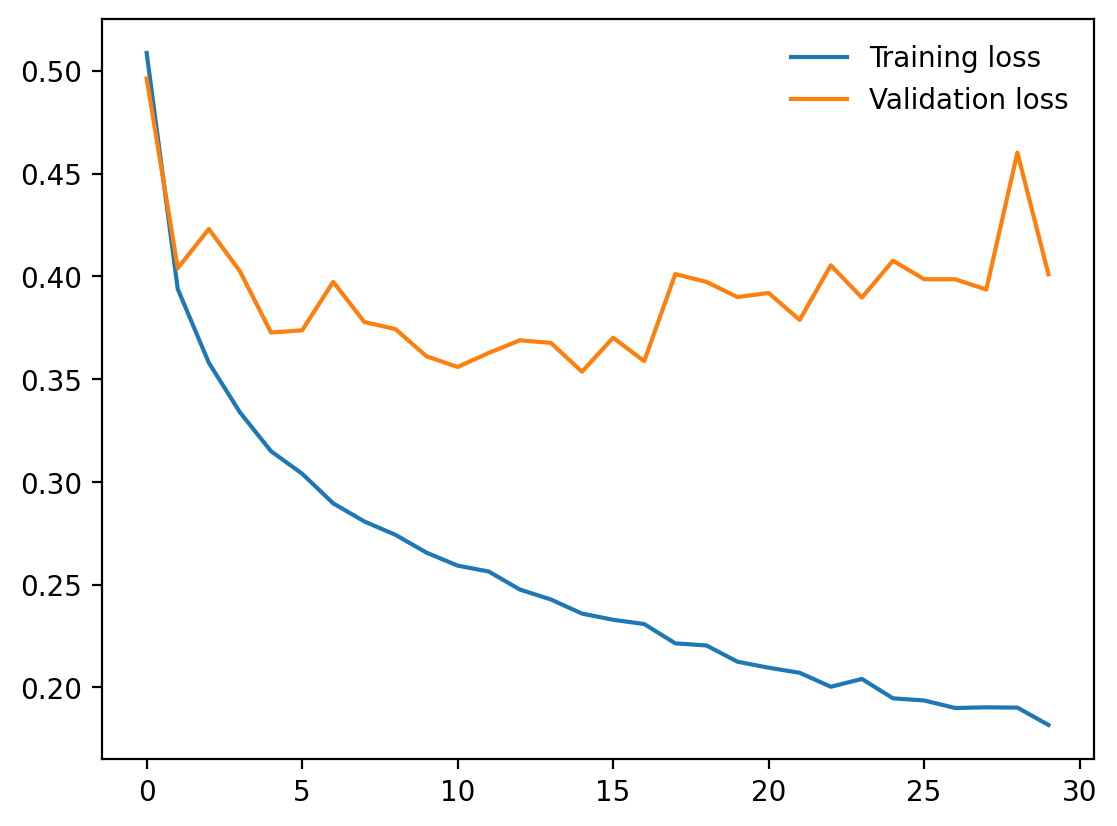

In [8]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

In [9]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

        # Dropout module with 0.2 drop probability
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)

        # Now with dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))

        # output so no dropout here
        x = F.log_softmax(self.fc4(x), dim=1)

        return x

In [ ]:
model = Classifier()
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 30
steps = 0

train_losses, test_losses = [], []
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        
        optimizer.zero_grad()
        
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    else:
        test_loss = 0
        accuracy = 0
        
        # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                log_ps = model(images)
                test_loss += criterion(log_ps, labels)
                
                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                accuracy += torch.mean(equals.type(torch.FloatTensor))
        
        model.train()
        
        train_losses.append(running_loss/len(trainloader))
        test_losses.append(test_loss/len(testloader))

        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(train_losses[-1]),
              "Test Loss: {:.3f}.. ".format(test_losses[-1]),
              "Test Accuracy: {:.3f}".format(accuracy/len(testloader)))

Epoch: 1/30..  Training Loss: 0.618..  Test Loss: 0.512..  Test Accuracy: 0.816
Epoch: 2/30..  Training Loss: 0.485..  Test Loss: 0.450..  Test Accuracy: 0.837
Epoch: 3/30..  Training Loss: 0.452..  Test Loss: 0.428..  Test Accuracy: 0.843
Epoch: 4/30..  Training Loss: 0.431..  Test Loss: 0.434..  Test Accuracy: 0.845
Epoch: 5/30..  Training Loss: 0.424..  Test Loss: 0.395..  Test Accuracy: 0.857
Epoch: 6/30..  Training Loss: 0.414..  Test Loss: 0.381..  Test Accuracy: 0.864
Epoch: 7/30..  Training Loss: 0.407..  Test Loss: 0.393..  Test Accuracy: 0.863
Epoch: 8/30..  Training Loss: 0.396..  Test Loss: 0.413..  Test Accuracy: 0.862
Epoch: 9/30..  Training Loss: 0.395..  Test Loss: 0.394..  Test Accuracy: 0.859
Epoch: 10/30..  Training Loss: 0.388..  Test Loss: 0.390..  Test Accuracy: 0.861
Epoch: 11/30..  Training Loss: 0.384..  Test Loss: 0.372..  Test Accuracy: 0.870
Epoch: 12/30..  Training Loss: 0.384..  Test Loss: 0.389..  Test Accuracy: 0.865
